In [2]:
from e3nn import o3
from mace.modules.blocks import tp_out_irreps_with_instructions

/home/snw30/miniconda3/envs/threedscriptors/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _Jd, _W3j_flat, _W3j_indices = 

In [ ]:
input_irreps = "128x0e+128x0e+128x1o"

i_in1 = o3.Irreps(input_irreps)
#i_in1 = i_in1.simplify()
print(i_in1)
embedding_dim = 32

proj = o3.Linear(i_in1, irreps_out = o3.Irreps(f"{embedding_dim}x0e+{embedding_dim}x1o"))

print(proj.weight_numel)
proj.irreps_out


ts = o3.TensorSquare(i_in1, irreps_out= f"{embedding_dim}x1e+{embedding_dim}x1o")
ts_out = ts.irreps_out.simplify()
print(ts_out)

irreps_mid, instructions = tp_out_irreps_with_instructions(
    ts_out,
    ts_out,
    o3.Irreps(f"{embedding_dim}x0o"),
)
tp_2 = o3.TensorProduct(
        ts_out,
       ts_out,
    irreps_mid,
    instructions=instructions,
    shared_weights=True,
    internal_weights=True,
)

tp_2.visualize()



128x0e+128x0e+128x1o
12288
32x1e+32x1o
2048
32x0o+32x0o


/home/snw30/miniconda3/envs/threedscriptors/lib/python3.12/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/snw30/miniconda3/envs/threedscriptors/lib/python3.12/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
/home/snw30/miniconda3/envs/threedscriptors/lib/python3.12/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.j

/home/snw30/miniconda3/envs/threedscriptors/lib/python3.12/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


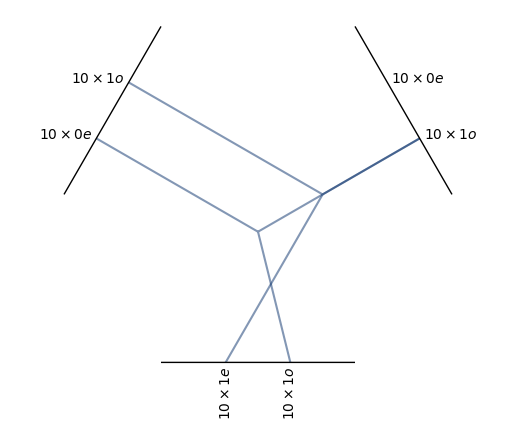

200


/home/snw30/miniconda3/envs/threedscriptors/lib/python3.12/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


(<Figure size 640x480 with 1 Axes>, <Axes: >)

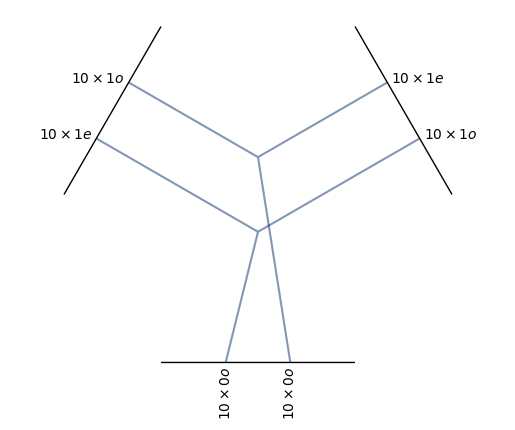

/home/snw30/miniconda3/envs/threedscriptors/lib/python3.12/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


(<Figure size 640x480 with 1 Axes>, <Axes: >)

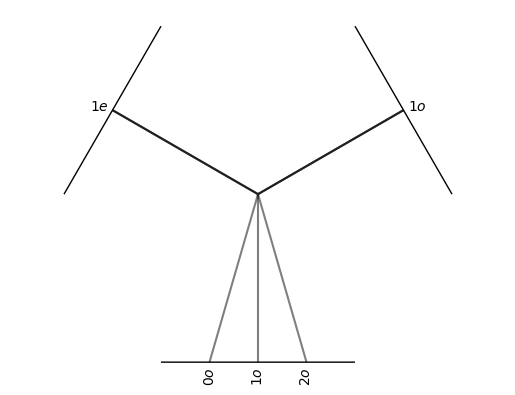

In [14]:
tp3 = o3.FullTensorProduct("1e","1o")
tp3.visualize()